29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


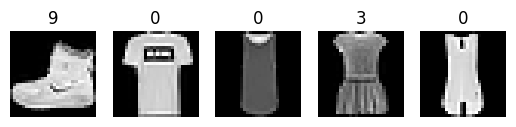

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8221 - loss: 0.4980 - val_accuracy: 0.8612 - val_loss: 0.3786
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8623 - loss: 0.3717 - val_accuracy: 0.8537 - val_loss: 0.3997
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8752 - loss: 0.3350 - val_accuracy: 0.8668 - val_loss: 0.3604
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8854 - loss: 0.3070 - val_accuracy: 0.8779 - val_loss: 0.3404
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8930 - loss: 0.2887 - val_accuracy: 0.8790 - val_loss: 0.3354
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8967 - loss: 0.2762 - val_accuracy: 0.8762 - val_loss: 0.3531
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9000 - loss: 0.2627 - val_accuracy: 0.8868 - val_loss: 0.3231
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9052 - loss: 0.24

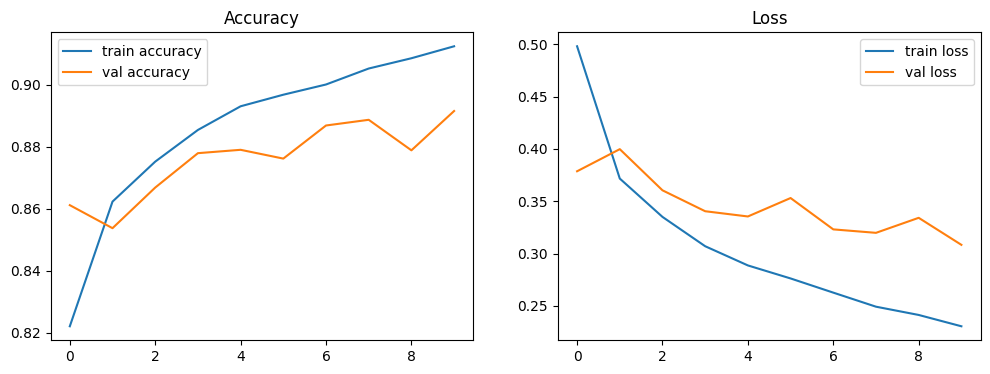

In [1]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from tensorflow.keras import models,layers

(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()

X_train_dense=X_train/255.0
X_test_dense=X_test/255.0
X_train_cnn=X_train.reshape(-1,28,28,1)/255.0
X_test_cnn=X_test.reshape(-1,28,28,1)/255.0
print(X_train_dense.shape)
print(X_train_cnn.shape)

baseline_model=models.Sequential([
  layers.Flatten(input_shape=(28,28)),layers.Dense(256,activation='relu'),
  layers.Dense(128,activation='relu'),layers.Dense(10,activation='softmax')
])

baseline_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i],cmap='gray')
  plt.title(y_train[i])
  plt.axis('off')
plt.show()

history=baseline_model.fit(X_train_dense,y_train,epochs=10,batch_size=32,validation_split=0.2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.show()

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7857 - loss: 0.5925 - val_accuracy: 0.8453 - val_loss: 0.4251
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8385 - loss: 0.4448 - val_accuracy: 0.8593 - val_loss: 0.3893
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8519 - loss: 0.4094 - val_accuracy: 0.8647 - val_loss: 0.3741
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8618 - loss: 0.3817 - val_accuracy: 0.8625 - val_loss: 0.3759
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8642 - loss: 0.3701 - val_accuracy: 0.8736 - val_loss: 0.3483
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8683 - loss: 0.3584 - val_accuracy: 0.8785 - val_loss: 0.3423
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8742 - loss: 0.3437 - val_accuracy: 0.8783 - val_loss: 0.3324
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8749 - loss: 0

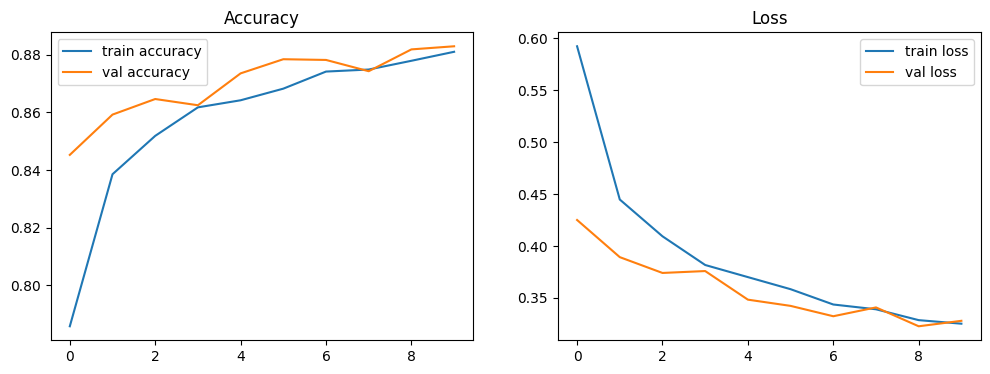

In [2]:
dropout_model=models.Sequential([
  layers.Flatten(input_shape=(28,28)),layers.Dense(256,activation='relu'),layers.Dropout(0.3),
  layers.Dense(128,activation='relu'),layers.Dropout(0.3),layers.Dense(10,activation='softmax')
])
dropout_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
dropout_history=dropout_model.fit(X_train_dense,y_train,epochs=10,batch_size=32,validation_split=0.2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(dropout_history.history['accuracy'], label='train accuracy')
plt.plot(dropout_history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(dropout_history.history['loss'], label='train loss')
plt.plot(dropout_history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.8224 - loss: 0.4940 - val_accuracy: 0.8708 - val_loss: 0.3648
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.8809 - loss: 0.3313 - val_accuracy: 0.8791 - val_loss: 0.3322
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.8992 - loss: 0.2816 - val_accuracy: 0.8916 - val_loss: 0.3011
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9083 - loss: 0.2535 - val_accuracy: 0.8945 - val_loss: 0.2964
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9181 - loss: 0.2265 - val_accuracy: 0.9097 - val_loss: 0.2532
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.9249 - loss: 0.2045 - val_accuracy: 0.9087 - val_loss: 0.2611
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9314 - loss: 0.1858 - val_accuracy: 0.9018 - val_loss: 0.2832
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9386 -

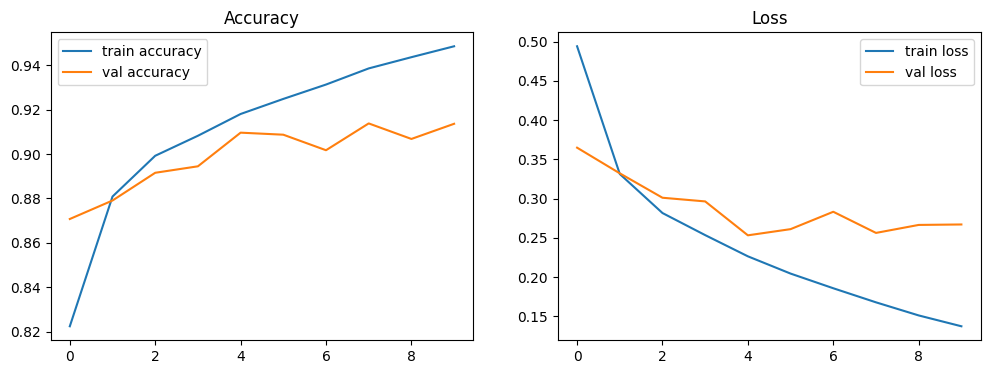

In [3]:
cnn_models=models.Sequential([
  layers.Conv2D(32,(3,3),activation='relu',
  input_shape=(28,28,1)),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(64,(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Flatten(),
  layers.Dense(64,activation='relu'),
  layers.Dense(10,activation='softmax')
])

cnn_models.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnn_history=cnn_models.fit(X_train_cnn,y_train,epochs=10,batch_size=32,validation_split=0.2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='train accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='train loss')
plt.plot(cnn_history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.show()

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9406 - loss: 0.1569 - val_accuracy: 0.8964 - val_loss: 0.3551
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9410 - loss: 0.1527 - val_accuracy: 0.8915 - val_loss: 0.3793
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9436 - loss: 0.1485 - val_accuracy: 0.8904 - val_loss: 0.3932
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9452 - loss: 0.1411 - val_accuracy: 0.8943 - val_loss: 0.4108
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9489 - loss: 0.1338 - val_accuracy: 0.8944 - val_loss: 0.3941
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9467 - loss: 0.1372 - val_accuracy: 0.8930 - val_loss: 0.3867
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9492 - loss: 0.1309 - val_accuracy: 0.8886 - val_loss: 0.4021
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9516 - loss: 0.

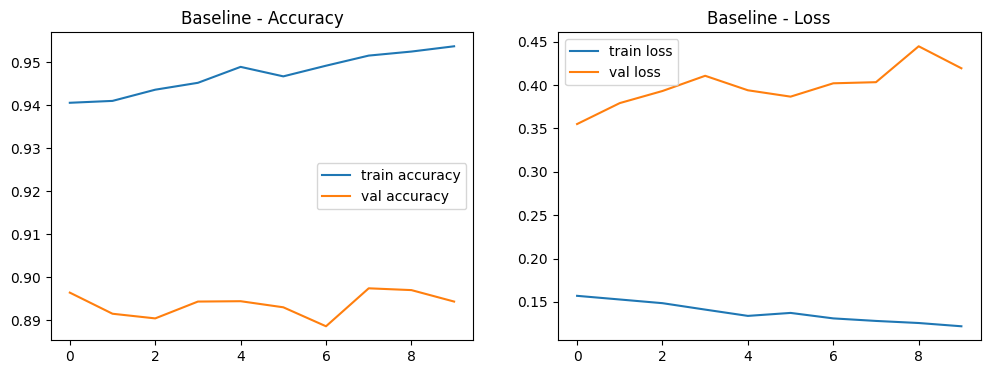

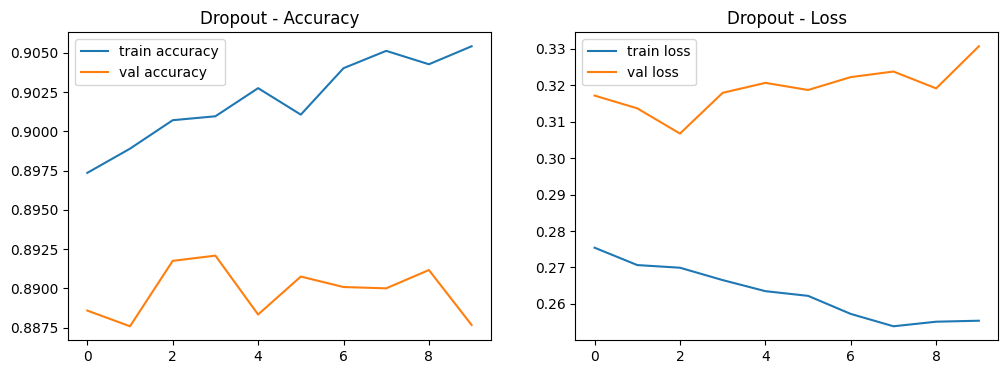

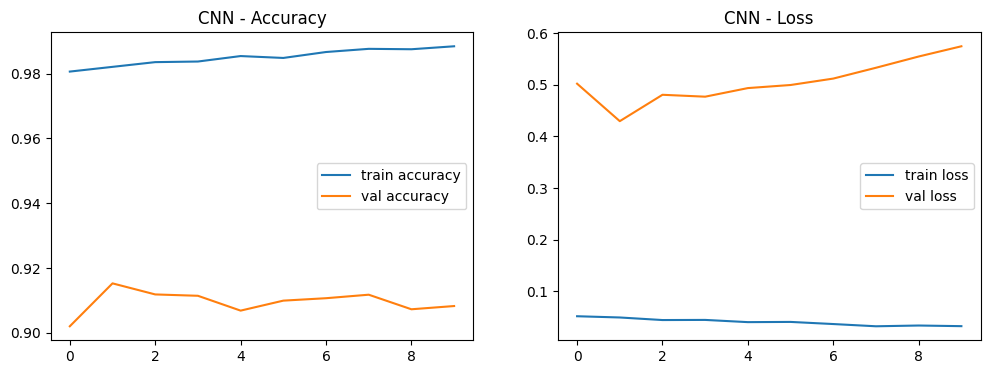

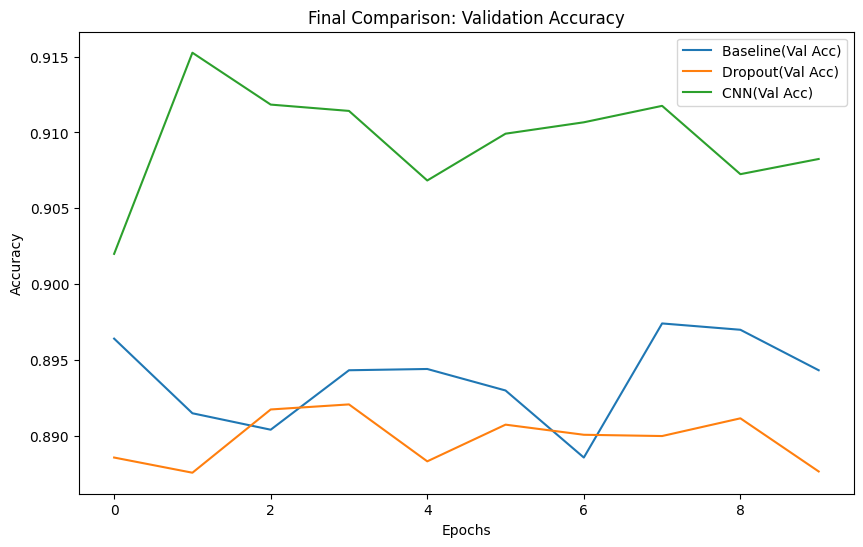

In [9]:
models_to_train=[
  (baseline_model,X_train_dense,"Baseline"),
  (dropout_model,X_train_dense,"Dropout"),
  (cnn_models,X_train_cnn,"CNN")
]

histories={}

for model,data,name in models_to_train:
  his=model.fit(data,y_train,epochs=10,batch_size=32,validation_split=0.2)
  histories[name]=his
for name in histories:
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(histories[name].history['accuracy'], label='train accuracy')
  plt.plot(histories[name].history['val_accuracy'], label='val accuracy')
  plt.title(f'{name} - Accuracy')
  plt.legend()
  plt.subplot(1, 2, 2)
  plt.plot(histories[name].history['loss'], label='train loss')
  plt.plot(histories[name].history['val_loss'], label='val loss')
  plt.title(f'{name} - Loss')
  plt.legend()
  plt.show()
plt.figure(figsize=(10, 6))
for name in histories:
    val_acc=histories[name].history['val_accuracy']
    plt.plot(val_acc,label=f'{name}(Val Acc)')
plt.title('Final Comparison: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [5]:
test_results={}

loss_base,acc_base=baseline_model.evaluate(X_test_dense,y_test,verbose=1)
test_results["Baseline"]=acc_base
loss_drop,acc_drop=dropout_model.evaluate(X_test_dense,y_test,verbose=1)
test_results["Dropout"]=acc_drop
loss_cnn,acc_cnn=cnn_models.evaluate(X_test_cnn,y_test,verbose=1)
test_results["CNN"]=acc_cnn

print(f"{'Model':<15} | {'Test Accuracy':<15}")
print("-"*40)
for name,acc in test_results.items():
    print(f"{name:<15} | {acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8874 - loss: 0.4291
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8835 - loss: 0.3347
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9015 - loss: 0.4389
Model           | Test Accuracy  
----------------------------------------
Baseline        | 0.8874
Dropout         | 0.8835
CNN             | 0.9015


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Max Val Acc: 0.8915
Max Val Acc: 0.8915
Max Val Acc: 0.8915


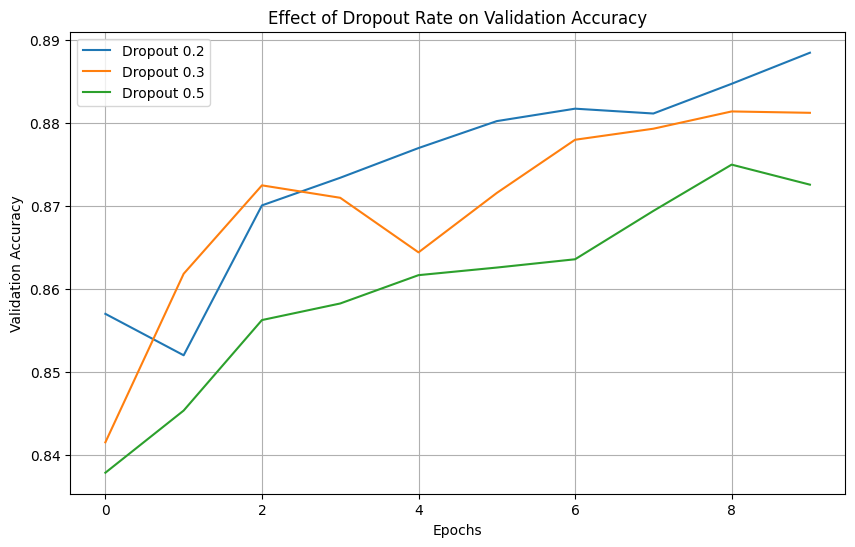

In [6]:
dropout_rates=[0.2,0.3,0.5]
dropout_histories={}

for rate in dropout_rates:
  model=models.Sequential([
      layers.Flatten(input_shape=(28, 28)),
      layers.Dense(256, activation='relu'),
      layers.Dropout(rate),
      layers.Dense(128, activation='relu'),
      layers.Dropout(rate),
      layers.Dense(10, activation='softmax')
      ])

  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  drop_his=model.fit(X_train_dense,y_train,
                     epochs=10, batch_size=32,
                     validation_split=0.2,verbose=0)
  dropout_histories[rate]=drop_his
print(f"Max Val Acc: {max(history.history['val_accuracy']):.4f}")

plt.figure(figsize=(10, 6))
for rate in dropout_rates:
    plt.plot(dropout_histories[rate].history['val_accuracy'], label=f'Dropout {rate}')

plt.title('Effect of Dropout Rate on Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8135 - loss: 0.5169 - val_accuracy: 0.8701 - val_loss: 0.3714
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8735 - loss: 0.3495 - val_accuracy: 0.8748 - val_loss: 0.3459
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.8886 - loss: 0.3049 - val_accuracy: 0.8897 - val_loss: 0.3048
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9007 - loss: 0.2760 - val_accuracy: 0.8904 - val_loss: 0.3082
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9071 - loss: 0.2521 - val_accuracy: 0.8975 - val_loss: 0.2772
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.8213 - loss: 0.4944 - val_accuracy: 0.8622 - val_loss: 0.3784
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.8796 - loss: 0.3333 - val_accuracy: 0.8867 - val_loss: 0.3128
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.8967 - loss: 0

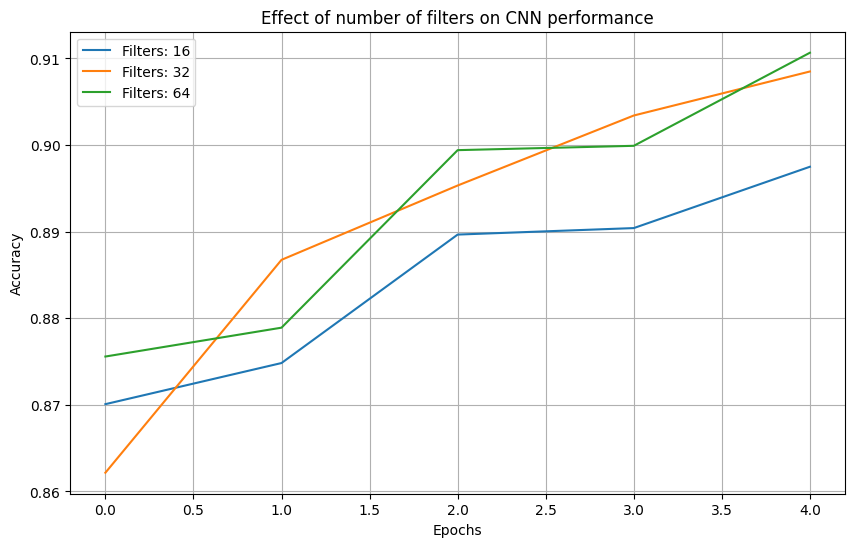

In [7]:
filter_options=[16, 32, 64]
filter_histories={}

for f in filter_options:
  model=models.Sequential([
      layers.Conv2D(f,(3, 3),activation='relu',input_shape=(28,28,1)),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(f*2,(3,3),activation='relu'),
      layers.MaxPooling2D((2,2)),
      layers.Flatten(),
      layers.Dense(64,activation='relu'),
      layers.Dense(10,activation='softmax')
      ])
  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

  history=model.fit(X_train_cnn, y_train,
                    epochs=5,batch_size=32,
                    validation_split=0.2,verbose=1)

  filter_histories[f]=history
plt.figure(figsize=(10, 6))

for f in filter_options:
    plt.plot(filter_histories[f].history['val_accuracy'], label=f'Filters: {f}')

plt.title('Effect of number of filters on CNN performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


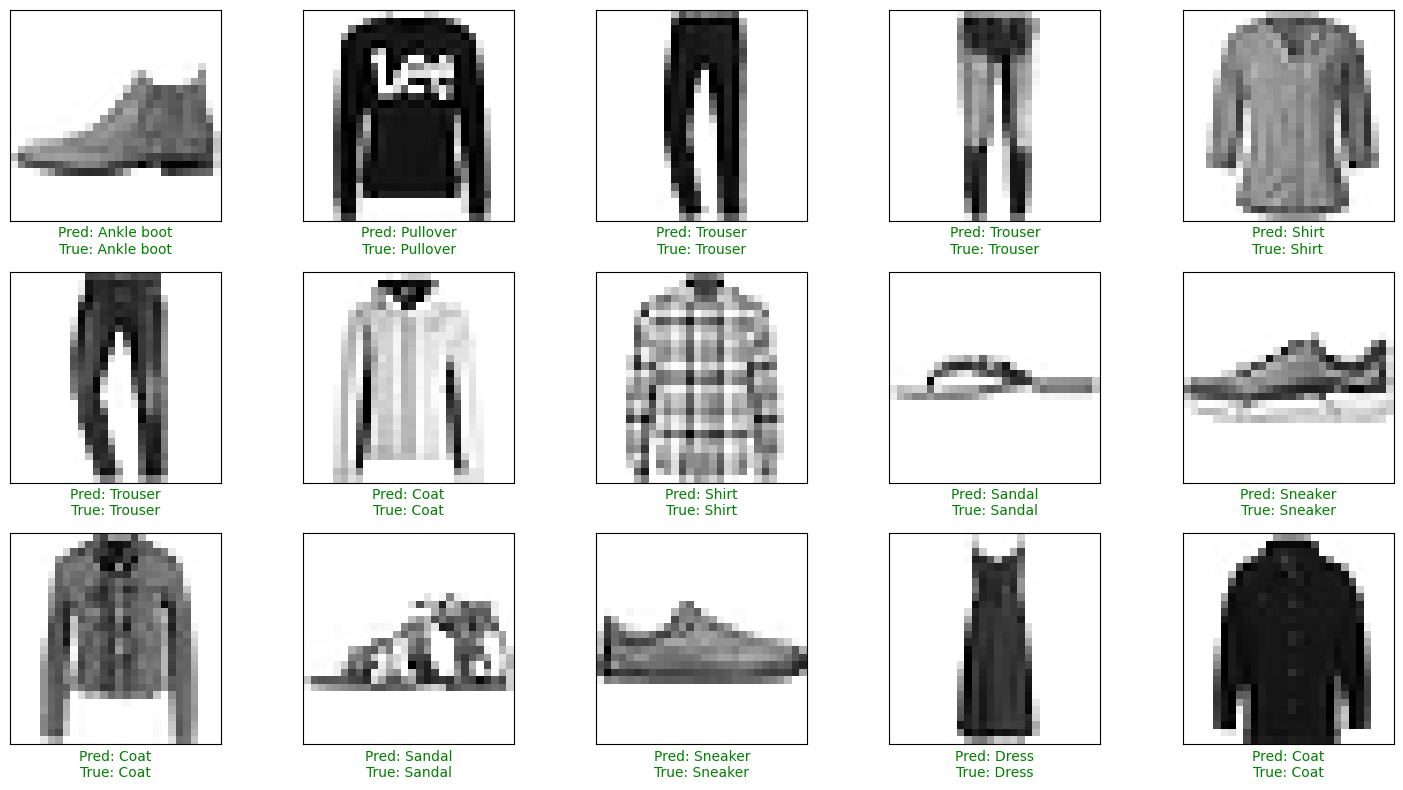

In [8]:
import numpy as np

num_images=15
test_images_sample=X_test_cnn[:num_images]
true_labels=y_test[:num_images]

predictions=cnn_models.predict(test_images_sample)

predicted_labels=np.argmax(predictions,axis=1)

class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(15,8))
for i in range(num_images):
    plt.subplot(3,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test[i],cmap=plt.cm.binary)

    color='green' if predicted_labels[i]==true_labels[i] else 'red'

    plt.xlabel(f"Pred: {class_names[predicted_labels[i]]}\nTrue: {class_names[true_labels[i]]}",color=color)
plt.tight_layout()
plt.show()